Para esta notebook se usan los Datos Históricos de **Caudal Medio Diario** y de **Altura** de la **Estacion 3050 - Túnel Subfluvial**

Fuente: https://snih.hidricosargentina.gob.ar

In [ ]:
# Importo librerias necesarias
import pandas as pd
import matplotlib.pyplot as plt

## Importación de ambos datasets


- Importamos sin la primer fila, que es el titulo y no forma parte de la tabla
- Corregimos el tipo de la columna Fecha y Hora, para que pandas sepa que es un dato de tiempo

In [ ]:
url = "https://raw.githubusercontent.com/YasminMondinoLl/SeriesTemporales_2026/main/DatosHistoricos-Estacion3050.xlsx"

datos_caudal = pd.read_excel(url, header = 1)


In [ ]:
datos_caudal["Fecha y Hora"] = pd.to_datetime(datos_caudal["Fecha y Hora"],
                                       dayfirst = True)

datos_caudal = datos_caudal.rename(columns={"Caudal Medio Diario [m3/seg]": "Caudal"})    # Acortamos el nombre para simplificar

datos_caudal.head()

,Fecha y Hora,Caudal
0,1904-01-25 07:43:00,17182.9
1,1904-01-26 07:43:00,17227.5
2,1904-01-27 07:43:00,17452.0
3,1904-01-28 07:43:00,17588.1
4,1904-01-29 07:43:00,17679.4


In [ ]:
url = "https://raw.githubusercontent.com/YasminMondinoLl/SeriesTemporales_2026/main/Altura-Estacion3050.xlsx"

datos_altura = pd.read_excel(url, header = 1)


In [ ]:
datos_altura["Fecha y Hora"] = pd.to_datetime(datos_altura["Fecha y Hora"],
                                       dayfirst = True)

datos_altura = datos_altura.rename(columns={"Altura [m]": "Altura"})    # Acortamos el nombre para simplificar

datos_altura.head()

,Fecha y Hora,Altura
0,1904-01-25 04:43:00,3.78
1,1904-01-26 04:43:00,3.79
2,1904-01-27 04:43:00,3.84
3,1904-01-28 04:43:00,3.87
4,1904-01-29 04:43:00,3.89


## Cálculos previos

Primero comparamos cuantos datos tenemos de cada variable

In [ ]:
print(f"El dataset de caudal tiene {datos_caudal.shape[0]} filas")
print(f"El dataset de altura tiene {datos_altura.shape[0]} filas")

El dataset de caudal tiene 44569 filas
El dataset de altura tiene 88932 filas


Para facilitar la comparación hacemos una columna en ambas tablas con el dato de Fecha únicamente

In [ ]:
datos_caudal["Fecha"] = datos_caudal["Fecha y Hora"].dt.normalize()
datos_altura["Fecha"] = datos_altura["Fecha y Hora"].dt.normalize()

Analizamos si alguno de los dos datasets tiene más de un dato para una misma fecha

In [ ]:
datos_caudal["Fecha"].duplicated().sum()

np.int64(0)

In [ ]:
datos_altura["Fecha"].duplicated().sum()

np.int64(44659)

In [ ]:
datos_altura[datos_altura["Fecha"].duplicated(keep=False)]

,Fecha y Hora,Altura,Fecha
36056,2003-02-05 06:00:00,3.36,2003-02-05
36057,2003-02-05 11:31:00,3.40,2003-02-05
36058,2003-02-05 12:09:00,3.40,2003-02-05
36169,2003-05-27 06:00:00,3.20,2003-05-27
36170,2003-05-27 08:00:00,3.18,2003-05-27
...,...,...,...
88927,2026-07-31 19:00:00,2.84,2026-07-31
88928,2026-07-31 20:00:00,2.84,2026-07-31
88929,2026-07-31 21:00:00,2.84,2026-07-31
88930,2026-07-31 22:00:00,2.84,2026-07-31


Como muchas fechas tienen más de un dato de altura, uso la siguiente función que agrupa los datos según la fecha y calcula el promedio de los valores de altura para cada fecha. El reset_index es para volver a enumerar correctamente las filas de la tabla

In [ ]:
datos_altura = datos_altura.groupby("Fecha")["Altura"].mean().reset_index()
datos_altura

,Fecha,Altura
0,1904-01-25,3.780000
1,1904-01-26,3.790000
2,1904-01-27,3.840000
3,1904-01-28,3.870000
4,1904-01-29,3.890000
...,...,...
44268,2026-07-27,2.691250
44269,2026-07-28,2.711667
44270,2026-07-29,2.743750
44271,2026-07-30,2.780417


Revisamos nuevamente si has fechas duplicadas

In [ ]:
datos_altura["Fecha"].duplicated().sum()

np.int64(0)

## Correlación

Necesitamos que las observaciones de las dos variables estén correctamente emparejadas en el tiempo. No es necesario que existan datos para todos los días.

Usamos **pd.merge** para crear una nueva tabla únicamente con los datos de las fechas para las cuales tenemos ambos datos: Caudal y Altura

In [ ]:
datos_corr = pd.merge(
                datos_caudal,
                datos_altura,
                on = "Fecha",
                how = "inner" # Se queda con las filas que comparten el mismo valor en Fecha
            )
datos_corr

,Fecha y Hora,Caudal,Fecha,Altura
0,1904-01-25 07:43:00,17182.90,1904-01-25,3.780000
1,1904-01-26 07:43:00,17227.50,1904-01-26,3.790000
2,1904-01-27 07:43:00,17452.00,1904-01-27,3.840000
3,1904-01-28 07:43:00,17588.10,1904-01-28,3.870000
4,1904-01-29 07:43:00,17679.40,1904-01-29,3.890000
...,...,...,...,...
44243,2026-07-27 00:00:00,14177.35,2026-07-27,2.691250
44244,2026-07-28 00:00:00,14233.51,2026-07-28,2.711667
44245,2026-07-29 00:00:00,14322.34,2026-07-29,2.743750
44246,2026-07-30 00:00:00,14423.06,2026-07-30,2.780417


Podemos calcular el coeficiente de correlación usando la función **corr**

In [ ]:
corr = datos_corr["Caudal"].corr(datos_corr["Altura"])

In [ ]:
print(f"Coeficiente de correlación: {corr:.3f}")


Coeficiente de correlación: 0.973


Graficamos una variable en función de la otra para observar la correlación entre ambas

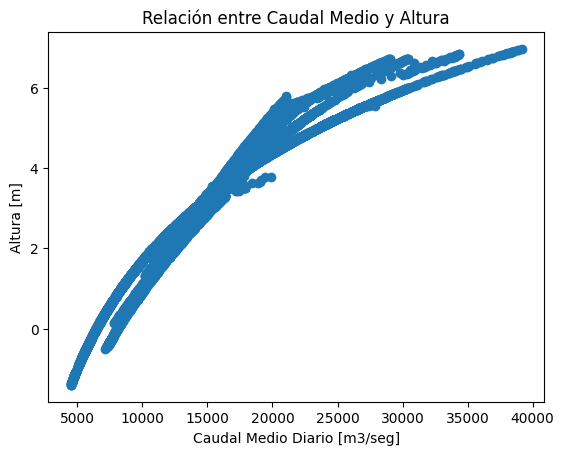

In [ ]:
plt.scatter(datos_corr["Caudal"], datos_corr["Altura"])
plt.xlabel("Caudal Medio Diario [m3/seg]")
plt.ylabel("Altura [m]")
plt.title("Relación entre Caudal Medio y Altura")
plt.show();

## Autocorrelación

Para poder calcular correctamente la autocorrelación necesitamos conocer correctamente la separación temporal entre observaciones. Es decir, necesitamos que los datos estén igualmente espaciados.

In [ ]:
fechas_esperadas = pd.date_range(
                              start = datos_caudal["Fecha"].min(),
                              end = datos_caudal["Fecha"].max(),
                              freq = "D"
                          )

fechas_faltantes = fechas_esperadas.difference(datos_caudal["Fecha"])

print("Cantidad de días faltantes:", len(fechas_faltantes))
print(fechas_faltantes)

Cantidad de días faltantes: 180
DatetimeIndex(['1904-04-01', '1904-04-02', '1904-04-03', '1904-04-04',
               '1904-04-05', '1904-04-06', '1904-04-07', '1904-04-08',
               '1904-04-09', '1904-04-10',
               ...
               '2019-10-21', '2019-10-22', '2019-10-23', '2019-10-24',
               '2019-10-25', '2019-10-26', '2019-10-27', '2019-10-28',
               '2019-10-29', '2019-10-30'],
              dtype='datetime64[ns]', length=180, freq=None)


Podemos visualizar las fechas faltantes

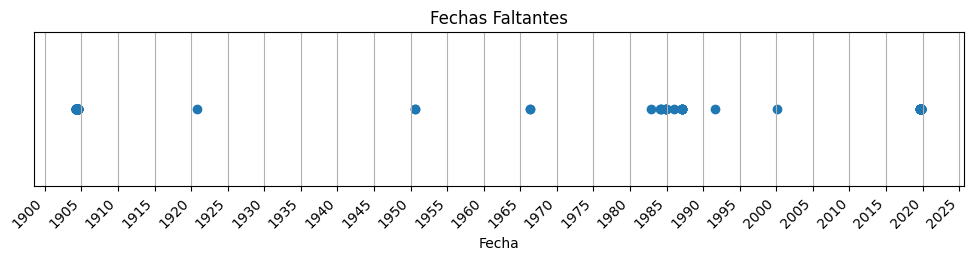

In [ ]:
import matplotlib.dates as mdates # Libreria que sirve para hacer el grid del plot más personalizable

plt.figure(figsize=(12, 2))

plt.scatter(
            fechas_faltantes,
            [1] * len(fechas_faltantes)
        )

plt.yticks([])
plt.xlabel("Fecha")
plt.title("Fechas Faltantes")
plt.grid()

plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))        # Permite hacer el grid cada 5 años
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')                             # Pone los valores del eje x en 45º

plt.show()

Podemos visualizar mejor las fechas faltantes de un año mediante un calendario

In [ ]:
año = 1904

# Genero una serie con todos los días del año a analizar
todos_los_dias = pd.date_range(
                                start=f"{año}-01-01",
                                end=f"{año}-12-31",
                                freq="D"
                            )

# Hago un dataset que tenga en una columna la fecha
calendario = pd.DataFrame({"Fecha": todos_los_dias})

# En la segunda columna del dataset pongo si existe o no información de ese fecha en el dataset
calendario["Disponible"] = calendario["Fecha"].isin(datos_caudal["Fecha"])

# Coordenadas
calendario["Semana"] = calendario["Fecha"].dt.isocalendar().week.astype(int) # Numero de semana en el año
calendario["Día_semana"] = calendario["Fecha"].dt.dayofweek                  # Dia de la semana


calendario.head()

,Fecha,Disponible,Semana,Día_semana
0,1904-01-01,False,53,4
1,1904-01-02,False,53,5
2,1904-01-03,False,53,6
3,1904-01-04,False,1,0
4,1904-01-05,False,1,1


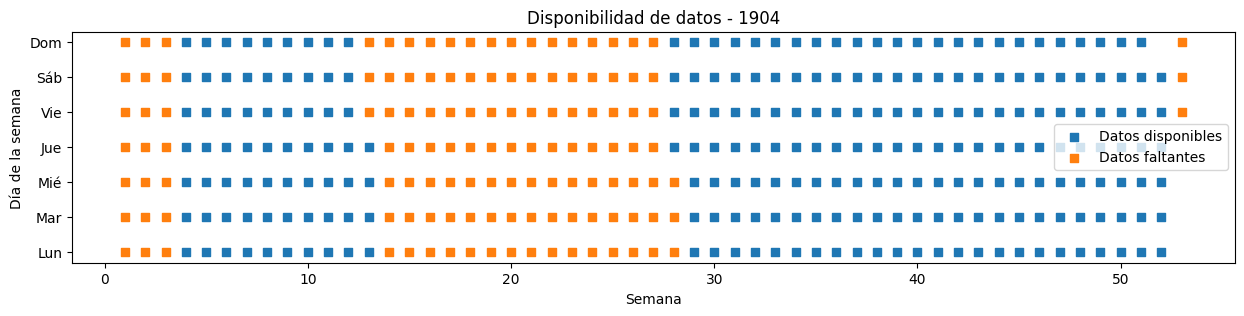

In [ ]:
plt.figure(figsize=(15, 3))

plt.scatter(
    calendario.loc[calendario["Disponible"], "Semana"],
    calendario.loc[calendario["Disponible"], "Día_semana"],
    marker = "s",
    label = "Datos disponibles"
)

plt.scatter(
    calendario.loc[~calendario["Disponible"], "Semana"],
    calendario.loc[~calendario["Disponible"], "Día_semana"],
    marker = "s",
    label = "Datos faltantes"
)

plt.yticks(
    range(7),
    ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
)

plt.xlabel("Semana")
plt.ylabel("Día de la semana")
plt.title(f"Disponibilidad de datos - {año}")

plt.legend()
plt.show()

Es posible analizar por mes cuantos datos hay para ver si hay algún mes en particular con menos datos

In [ ]:
datos_caudal["Mes"] = datos_caudal["Fecha"].dt.to_period("M") # Creo una columna con el Mes

datos_por_mes = datos_caudal.groupby("Mes").size()            # Agrupo los datos por mes y cuento cuántos hay en cada mes (no se mezclan los meses de distintos años)

# Para poder visualizarlo mejor me quedo con los datos desde el 2020
datos_5_años = datos_por_mes[datos_por_mes.index.year >= 2020]

datos_5_años.head()


,0
Mes,
2020-01,31
2020-02,29
2020-03,31
2020-04,30
2020-05,31


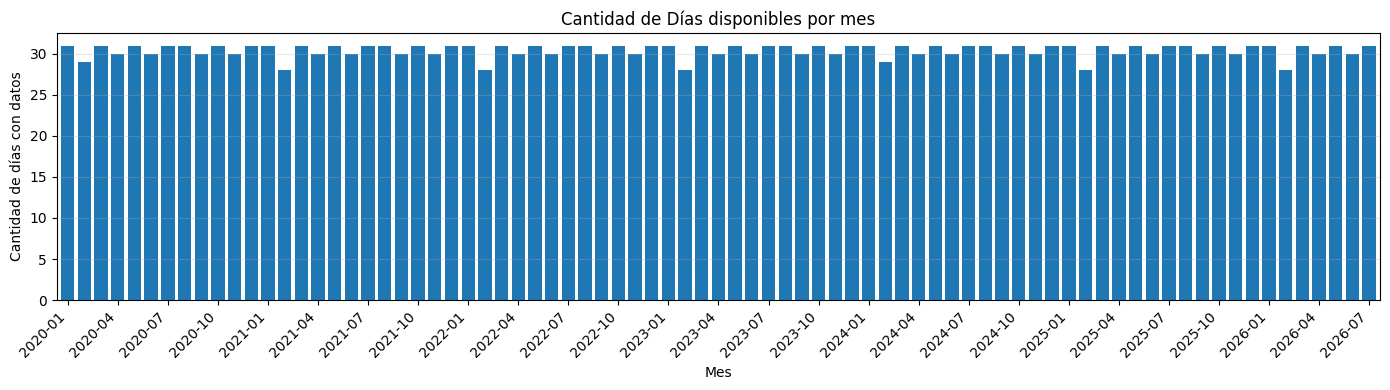

In [ ]:
ax = datos_5_años.plot(
                        kind = "bar",
                        figsize = (14, 4),
                        width = 0.8
                    )

ax.set_ylabel("Cantidad de días con datos")
ax.set_xlabel("Mes")
ax.set_title("Cantidad de Días disponibles por mes")

# Mostrar una etiqueta cada 3 meses
ax.set_xticks(range(0, len(datos_5_años), 3))
ax.set_xticklabels(
    [str(x) for x in datos_5_años.index[::3]],
    rotation=45,
    ha="right"
)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

En este punto es necesario elegir que datos usar para tener una serie de datos regularmente espaciada.

La opción simple sería rellenar los datos faltantes, en este caso interpolando

In [ ]:
datos_caudal_completo = (datos_caudal.set_index("Fecha")  # Usa temporalmente Fecha como índice
                      .reindex(fechas_esperadas)          # Reemplaza el índice por fechas_esperadas
                      .rename_axis("Fecha")               # Asigna el nombre "Fecha" al nuevo índice
                      .reset_index())                     # Convierte nuevamente el índice Fecha en una columna

datos_caudal_completo["Caudal"] = datos_caudal_completo["Caudal"].interpolate()

Importamos la función que permite graficar la autocorrelación

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

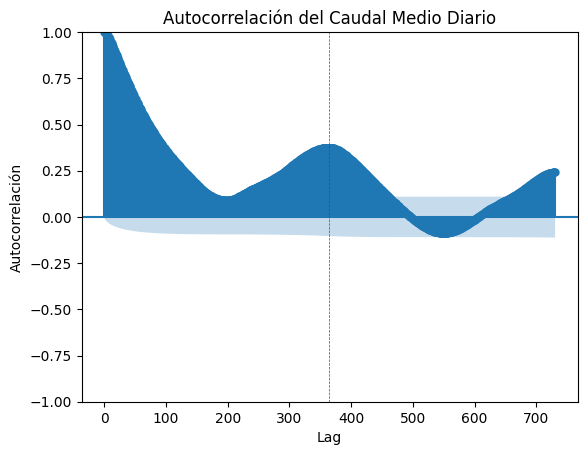

In [ ]:
plot_acf(datos_caudal_completo["Caudal"], lags = 730)

plt.xlabel("Lag")
plt.ylabel("Autocorrelación")
plt.title("Autocorrelación del Caudal Medio Diario")

plt.axvline(x=365, color='red', linestyle='--', linewidth=0.5) # Permite hacer lineas verticales en el gráfico
plt.show()

Las bandas sombreadas representan un intervalo de confianza del 95 % alrededor de cero bajo la hipótesis nula de ruido blanco. Si la serie fuera puramente aleatoria, aproximadamente el 95 % de los lags caerían dentro de estas bandas.

- Si la barra queda DENTRO: No hay evidencia suficiente para decir que existe correlación y rechazar la hipótesis nula. El valor es estadísticamente indistinguible de cero (ruido).
- Si la barra SOBRESALE: Se rechaza la hipótesis de aleatoriedad con un 95% de certeza. Existe una autocorrelación estadísticamente significativa en ese retraso (lag).


Importamos la función que permite hacer el cálculo de autocorrelación

In [ ]:
from statsmodels.tsa.stattools import acf

autocorr = acf(
    datos_caudal_completo["Caudal"],
    nlags=10
)

for lag, valor in enumerate(autocorr):
    print(f"Lag {lag}: {valor:.3f}")

Lag 0: 1.000
Lag 1: 0.999
Lag 2: 0.997
Lag 3: 0.994
Lag 4: 0.990
Lag 5: 0.986
Lag 6: 0.980
Lag 7: 0.974
Lag 8: 0.968
Lag 9: 0.961
Lag 10: 0.954


Podemos graficar un scatter para ver la autocorrelación para un determinado lag

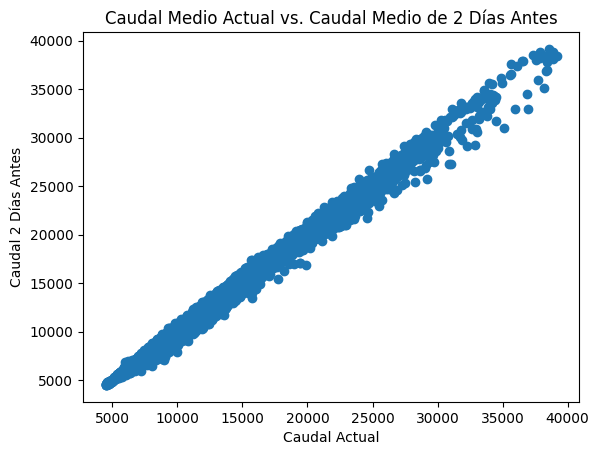

In [ ]:
lag = 2

plt.scatter(
       datos_caudal_completo["Caudal"].iloc[lag:],
       datos_caudal_completo["Caudal"].iloc[:-lag]
)

plt.xlabel("Caudal Actual")
plt.ylabel(f"Caudal {lag} Días Antes")
plt.title(f"Caudal Medio Actual vs. Caudal Medio de {lag} Días Antes")
plt.show();


Podemos calcular la autocorrelación para el lag específico de 365 días

In [ ]:
correlacion_anual = datos_caudal_completo["Caudal"].autocorr(lag = 365)

print(correlacion_anual)

0.375539930851251


Podemos graficar un scatter para ver la autocorrelación para un determinado número de años

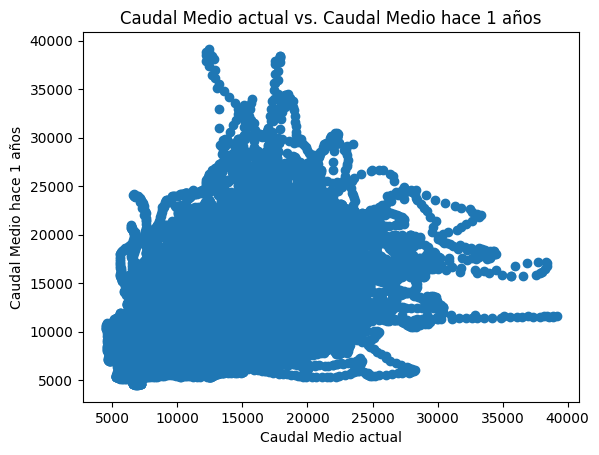

In [ ]:
años = 1

plt.scatter(
    datos_caudal_completo["Caudal"].iloc[365*años:],
    datos_caudal_completo["Caudal"].iloc[:-365*años]
)

plt.xlabel("Caudal Medio actual")
plt.ylabel(f"Caudal Medio hace {años} años")
plt.title(f"Caudal Medio actual vs. Caudal Medio hace {años} años")

plt.show()